In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torch.utils.data as data_utils
import torchvision.models as models
import numpy as np
import matplotlib.pyplot as plt
import os
import random

from dataclasses import dataclass, field
from torchmetrics.classification import MulticlassAccuracy

from dnnhelper import EarlyStopping, Experiment

from torchvision.datasets import MNIST

from torchsummary import summary

In [2]:
seed = 42

random.seed(seed)
os.environ['PYTHONHASHSEED'] = str(seed)
np.random.seed(seed)
torch.manual_seed(seed)

In [3]:
# load mnist dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [4]:
mnist_trainset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

In [5]:
mnist_testset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

In [6]:
mnist_trainset[0][1]

5

In [7]:
classes = mnist_trainset.classes

classes

['0 - zero',
 '1 - one',
 '2 - two',
 '3 - three',
 '4 - four',
 '5 - five',
 '6 - six',
 '7 - seven',
 '8 - eight',
 '9 - nine']

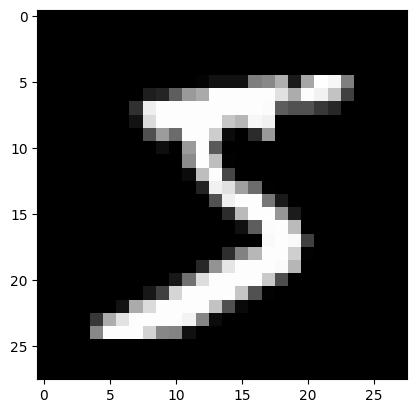

In [8]:
plt.imshow(mnist_trainset[0][0][0], cmap='gray')

In [9]:
train_dl = data_utils.DataLoader(mnist_trainset, batch_size=64, shuffle=True)
test_dl = data_utils.DataLoader(mnist_testset, batch_size=64, shuffle=False)

In [10]:
class SimpleCNN(nn.Module):

    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

        output_filters = 64

        # Define the layers of the CNN
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1) 
        self.conv2 = nn.Conv2d(32, output_filters, kernel_size=2, stride=2, padding=1)

        self.pool = nn.MaxPool2d(kernel_size=(3,3), stride=2, padding=1)

        self.flatten = nn.Flatten()

        self.global_avg_pool = nn.AdaptiveAvgPool2d((1, 1)) #(1, 1) = output size

        self.fc1 = nn.Linear(output_filters, 128)
        self.dropout = nn.Dropout(0.2)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):

        x = self.pool(F.relu(self.conv1(x))) 

        x = self.pool(F.relu(self.conv2(x)))

        x = self.global_avg_pool(x)

        x = self.flatten(x) # flatten the tensor, except for the batch dimension

        x = F.relu(self.fc1(x))

        x = self.dropout(x)

        x = self.fc2(x)

        return x

In [11]:
cnn = SimpleCNN()
summary(cnn, (1, 28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 14, 14]             320
         MaxPool2d-2             [-1, 32, 7, 7]               0
            Conv2d-3             [-1, 64, 4, 4]           8,256
         MaxPool2d-4             [-1, 64, 2, 2]               0
 AdaptiveAvgPool2d-5             [-1, 64, 1, 1]               0
           Flatten-6                   [-1, 64]               0
            Linear-7                  [-1, 128]           8,320
           Dropout-8                  [-1, 128]               0
            Linear-9                   [-1, 10]           1,290
Total params: 18,186
Trainable params: 18,186
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.07
Params size (MB): 0.07
Estimated Total Size (MB): 0.14
---------------------------------------------

In [12]:
experiments = []
val_loss_values_baseline = []
train_loss_values_baseline = []

baseline_exp = Experiment(
  name = "baseline",
  checkpoints_folder = 'models',
  checkpoint_name = "baseline.pt",
  model = SimpleCNN,
  use_early_stopping = True,
  loss_fn = nn.CrossEntropyLoss,
  optimizer= torch.optim.Adam,
  lr = 1e-3,
  epochs = 10,
  epoch_count =  10,
  early_stopping = EarlyStopping,
  patience= 5,
  val_loss_values = val_loss_values_baseline,
  train_loss_values = train_loss_values_baseline,
  color = "#FF7F0E",
  alpha = .3,
)

experiments.append(baseline_exp)

In [13]:
# Metric definitions

#Accuracy
accuracy_fn_train = MulticlassAccuracy(num_classes=len(classes), average='micro')
accuracy_fn_test = MulticlassAccuracy(num_classes=len(classes), average='micro')

In [14]:
def fit(exp:Experiment, trainloader, valloader):

  exp.train_loss_values = []
  exp.val_loss_values = []

  #epochs = exp.epochs
  for epoch in range(exp.epochs):

    #train mode over images of trainloader
    exp.model.train()
    loss_epoch = 0

    for _, data in enumerate(trainloader, 0):

      X = data[0]
      y = data[1]

      y_pred = exp.model(X)

      loss = exp.loss_fn(y_pred, y)

      accuracy_fn_train.update(y_pred, y)

      loss_epoch += loss

      exp.optimizer.zero_grad()

      loss.backward()

      exp.optimizer.step()
      
    loss_val = 0

    #validation mode over images of valloader
    exp.model.eval()

    for _, data in enumerate(valloader, 0):

      X = data[0]
      y = data[1]

      with torch.no_grad():

        y_pred = exp.model(X)
        loss = exp.loss_fn(y_pred, y)

        accuracy_fn_test.update(y_pred, y)

      loss_val += loss

    exp.train_loss_values.append(loss_epoch.detach().numpy()/len(trainloader))
    exp.val_loss_values.append(loss_val.detach().numpy()/len(valloader))

    epoch_accuracy_train = accuracy_fn_train.compute()
    epoch_accuracy_test = accuracy_fn_test.compute()

    print(f"Epoch: {epoch} |  Train Loss: {loss_epoch/len(trainloader):.3f} | Val Loss: {loss_val/len(valloader):.3f} | Train Accuracy: {epoch_accuracy_train:.3f} | Val Accuracy: {epoch_accuracy_test:.3f}")

    accuracy_fn_train.reset()
    accuracy_fn_test.reset()

    if exp.use_early_stopping:
      exp.early_stopping(loss_val/len(valloader), exp.model)
      if exp.early_stopping.early_stop:
        print("Early stopping all'epoca:", epoch)
        exp.model.load_state_dict(torch.load(exp.checkpoint_save_path))
        break
      

In [15]:
def evaluate(exp:Experiment, testloader):

  tot_loss = 0
  exp.model.eval()

  for j, data in enumerate(testloader, 0):

    X = data[0]
    y = data[1]

    with torch.no_grad():

      y_pred = exp.model(X)
      loss = exp.loss_fn(y_pred, y)

    tot_loss += loss
    
  return tot_loss.detach().numpy()/len(testloader)

In [16]:
for experiment in experiments:

    fit(experiment, train_dl, test_dl)
    test_loss = evaluate(experiment, test_dl)

Epoch: 0 |  Train Loss: 0.895 | Val Loss: 0.432 | Train Accuracy: 0.706 | Val Accuracy: 0.870
Epoch: 1 |  Train Loss: 0.383 | Val Loss: 0.269 | Train Accuracy: 0.883 | Val Accuracy: 0.918
Epoch: 2 |  Train Loss: 0.270 | Val Loss: 0.223 | Train Accuracy: 0.917 | Val Accuracy: 0.931
Epoch: 3 |  Train Loss: 0.217 | Val Loss: 0.181 | Train Accuracy: 0.934 | Val Accuracy: 0.945
Epoch: 4 |  Train Loss: 0.187 | Val Loss: 0.180 | Train Accuracy: 0.942 | Val Accuracy: 0.943
Epoch: 5 |  Train Loss: 0.166 | Val Loss: 0.143 | Train Accuracy: 0.949 | Val Accuracy: 0.956
Epoch: 6 |  Train Loss: 0.146 | Val Loss: 0.123 | Train Accuracy: 0.954 | Val Accuracy: 0.964
Epoch: 7 |  Train Loss: 0.135 | Val Loss: 0.118 | Train Accuracy: 0.957 | Val Accuracy: 0.963
Epoch: 8 |  Train Loss: 0.122 | Val Loss: 0.115 | Train Accuracy: 0.962 | Val Accuracy: 0.966
Epoch: 9 |  Train Loss: 0.117 | Val Loss: 0.115 | Train Accuracy: 0.963 | Val Accuracy: 0.964
